# 01 · Análise exploratória e construção da base de conhecimento

**Objetivo.** Antes de indexar qualquer coisa, entender os textos das avaliações o suficiente para tomar — e justificar — as decisões do requisito 1 do desafio: seleção dos dados, limpeza, valores ausentes, organização dos documentos e metadados.

Cada seção segue o mesmo formato: **pergunta → evidência (código) → decisão**.

> Fonte: *Brazilian E-Commerce Public Dataset by Olist* (Kaggle). Os CSVs ficam em `DATA_DIR` (ver `.env`).

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from voc_rag.config import get_settings
from voc_rag.data_prep import read_raw   # lê .csv ou .csv.gz
from voc_rag.text_utils import clean_for_embedding, dedup_key, normalize_for_rules

pd.set_option("display.max_colwidth", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
s = get_settings()
raw = s.data_dir
reviews = read_raw(raw, "olist_order_reviews_dataset.csv")
orders = read_raw(raw, "olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp",
                     "order_delivered_customer_date", "order_estimated_delivery_date"])
print(f"avaliações: {reviews.shape}  |  pedidos: {orders.shape}")
reviews.head(3)

avaliações: (99224, 7)  |  pedidos: (99441, 8)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


## 1. Quanto texto existe de fato?
Pergunta: quantas avaliações têm título e/ou comentário? O RAG só pode recuperar o que foi escrito.

In [2]:
aus = reviews[["review_comment_title", "review_comment_message"]].isna().mean().mul(100).round(1)
com_texto = reviews["review_comment_title"].notna() | reviews["review_comment_message"].notna()
print("% ausente por coluna:"); print(aus.to_string())
print(f"\nAvaliações com título OU comentário: {com_texto.sum():,} de {len(reviews):,} ({com_texto.mean():.1%})")
print(f"Só título, sem comentário: {(reviews.review_comment_title.notna() & reviews.review_comment_message.isna()).sum():,}")

% ausente por coluna:
review_comment_title      88.3
review_comment_message    58.7

Avaliações com título OU comentário: 42,706 de 99,224 (43.0%)
Só título, sem comentário: 1,729


**Decisão (valores ausentes).** Avaliações sem nenhum texto **não entram no índice vetorial** (não há o que recuperar), mas **permanecem na base completa** (`avaliacoes_todas.parquet`), porque são necessárias para estatísticas corretas na camada analítica. O título, quando existe, é concatenado ao comentário — inclusive nos ~1,7 mil casos em que só há título ("não recomendo" é informação).

## 2. Quem escreve comentários?
Pergunta: a decisão de comentar é independente da nota? Se não for, a base textual é uma amostra enviesada da clientela.

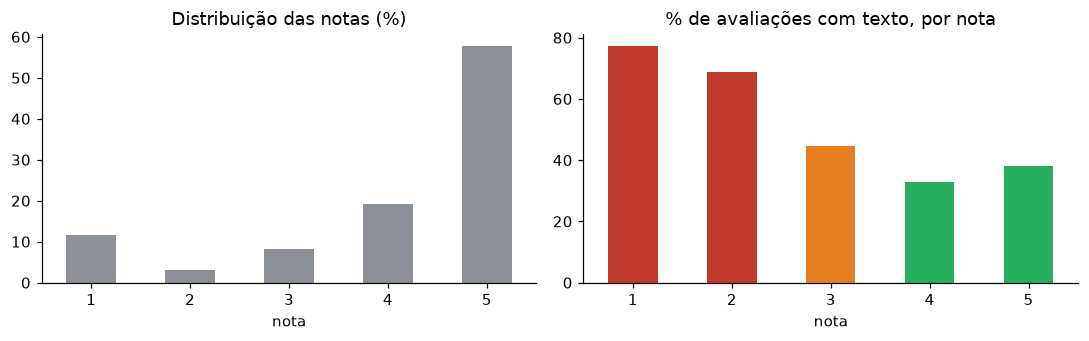

review_score,1,2,3,4,5
% com texto,77.3,68.7,44.6,32.8,38.0


In [3]:
taxa = reviews.assign(tem=com_texto).groupby("review_score")["tem"].mean().mul(100)
dist = reviews["review_score"].value_counts(normalize=True).sort_index().mul(100)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
dist.plot.bar(ax=ax[0], color="#8a8f98"); ax[0].set_title("Distribuição das notas (%)"); ax[0].set_xlabel("nota")
taxa.plot.bar(ax=ax[1], color=["#c0392b", "#c0392b", "#e67e22", "#27ae60", "#27ae60"])
ax[1].set_title("% de avaliações com texto, por nota"); ax[1].set_xlabel("nota")
for a in ax: a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
taxa.round(1).to_frame("% com texto").T

**Leitura.** Clientes insatisfeitos comentam com muito mais frequência (≈ 3 de cada 4 avaliações com nota 1) do que satisfeitos (≈ 1 em 3 nas notas 4–5). Consequências de projeto:
1. A base textual **sobrerrepresenta a insatisfação** — o que é bom para investigar problemas, mas exige cuidado ao falar em proporções.
2. Na camada analítica, percentuais são calculados **dentro de bases explícitas** (ex.: "entre as avaliações com comentário de nota 1–3") e a base é sempre informada junto com o número.

## 3. Unidade do documento: precisa de *chunking*?

count    40977.0
mean        11.7
std          9.6
min          0.0
50%          9.0
90%         28.0
99%         37.0
max         45.0

caracteres: máx = 208  |  mediana = 53


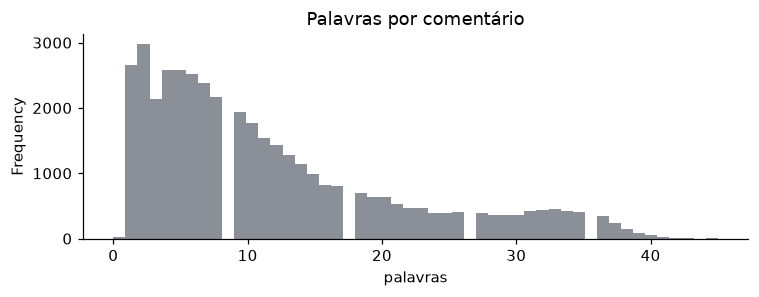

In [4]:
msg = reviews["review_comment_message"].dropna()
palavras = msg.str.split().str.len()
print(palavras.describe(percentiles=[.5, .9, .99]).round(1).to_string())
print(f"\ncaracteres: máx = {msg.str.len().max()}  |  mediana = {msg.str.len().median():.0f}")
ax = palavras.clip(upper=50).plot.hist(bins=50, color="#8a8f98", figsize=(7, 2.8))
ax.set_title("Palavras por comentário"); ax.set_xlabel("palavras"); plt.tight_layout(); plt.show()

**Decisão (organização dos documentos).** Os comentários são curtos (mediana ≈ 9 palavras; máximo de 208 caracteres). **Uma avaliação = um documento**, sem *chunking*: cortar um texto desse tamanho só destruiria a unidade de sentido, e cada evidência continua apontando para uma avaliação real e rastreável (`review_id`).

## 4. Duplicidades

In [5]:
dup_rows = reviews["review_id"].duplicated(keep=False)
g = reviews[dup_rows].groupby("review_id").agg(pedidos=("order_id", "nunique"),
        textos=("review_comment_message", lambda x: x.fillna("").nunique()), notas=("review_score", "nunique"))
print(f"linhas com review_id repetido: {reviews['review_id'].duplicated().sum()}  ({g.shape[0]} review_ids)")
print("Para todos eles, o texto e a nota são idênticos?", bool((g.textos == 1).all() and (g.notas == 1).all()))
textos = msg.map(dedup_key)
top = textos.value_counts().head(10)
print(f"\ncomentários literalmente repetidos (após normalizar): {textos.duplicated().mean():.1%}")
top.to_frame("ocorrências")

linhas com review_id repetido: 814  (789 review_ids)
Para todos eles, o texto e a nota são idênticos? True



comentários literalmente repetidos (após normalizar): 18.3%


,ocorrências
review_comment_message,
muito bom,598
otimo,471
bom,369
recomendo,316
excelente,214
otimo produto,168
ok,158
,150
tudo ok,131


**Decisões.**
- `review_id` repetido = a mesma avaliação ligada a 2–3 pedidos. Mantemos **um documento** e guardamos a lista de pedidos (`pedidos`).
- Textos idênticos ("muito bom", "recomendo"...) **são mantidos** na base (cada um é uma avaliação real e conta nas estatísticas), mas **deduplicados na recuperação**: o contexto do LLM recebe uma cópia, anotada com "texto idêntico em N avaliações". Sem isso, 8 vagas de contexto poderiam ser ocupadas pela mesma frase.

## 5. Limpeza e dados pessoais

In [6]:
crlf = msg.str.contains(r"\r|\n").sum()
exemplos_pii = msg[msg.str.contains(r"\(?\b\d{2}\)?\s?9?\s?\d{4}[-\s]?\d{4}\b|https?://|www\.", regex=True)]
print(f"comentários com quebra de linha: {crlf:,}")
print(f"comentários com telefone/URL: {len(exemplos_pii)}")
for t in exemplos_pii: print("  antes :", t[:110].replace("\r\n", " ⏎ ")); print("  depois:", clean_for_embedding(t)[:110])

comentários com quebra de linha: 3,852
comentários com telefone/URL: 4
  antes : comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto http://prntscr.com/
  depois: comprei o produto pela cor ilustrada pelo site da loja americana, no site mostra ser preto [URL] quando o prod
  antes : Faltou item descrito ⏎ Me ligue 34 99978 4951
  depois: Faltou item descrito Me ligue [TELEFONE]
  antes : Loja parceira de www.lannister.com e por isso merecedora de crédito.
  depois: Loja parceira de [URL] e por isso merecedora de crédito.
  antes : Aguardo o recebimento da minha encomenda com urgência... ⏎ No momento estou Insatisfeita com a empresa. ⏎ 98 988
  depois: Aguardo o recebimento da minha encomenda com urgência... No momento estou Insatisfeita com a empresa. [TELEFON


**Decisão (limpeza).** Para os **embeddings**, limpeza mínima: normalização Unicode (NFC — há "ótimo" em duas codificações diferentes), quebras de linha → espaço, espaços duplicados e **mascaramento de dados pessoais** (telefone, e-mail, CPF, URL). Acentos, caixa, pontuação e palavras como "não" são **mantidos**: modelos Transformer usam isso como sinal.

A limpeza pesada (minúsculas, sem acento, sem stopwords, *stemming*) é aplicada **apenas ao índice léxico (BM25)** — e mesmo lá as negações ("não", "nunca", "sem") são preservadas, porque em avaliações elas invertem o sentido.

## 6. Metadados que importam: a entrega explica a nota?

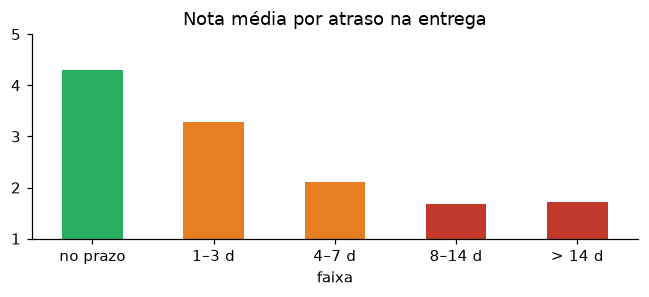

,n,nota_media,pct_nota_1_2
faixa,,,
no prazo,89240,4.29,9.22
1–3 d,1843,3.29,32.07
4–7 d,1746,2.11,67.58
8–14 d,1439,1.67,80.26
> 14 d,1333,1.72,78.39


In [7]:
o = orders[orders.order_status == "delivered"].copy()
o["atraso_dias"] = (o.order_delivered_customer_date.dt.normalize() - o.order_estimated_delivery_date.dt.normalize()).dt.days
x = reviews.drop_duplicates("review_id").merge(o[["order_id", "atraso_dias"]], on="order_id")
x["faixa"] = pd.cut(x.atraso_dias, [-1000, 0, 3, 7, 14, 1000], labels=["no prazo", "1–3 d", "4–7 d", "8–14 d", "> 14 d"])
t = x.groupby("faixa", observed=True).agg(n=("review_score", "size"), nota_media=("review_score", "mean"),
                                          pct_nota_1_2=("review_score", lambda v: (v <= 2).mean() * 100)).round(2)
ax = t["nota_media"].plot.bar(color=["#27ae60", "#e67e22", "#e67e22", "#c0392b", "#c0392b"], figsize=(6, 2.8))
ax.set_title("Nota média por atraso na entrega"); ax.set_ylim(1, 5); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show(); t

**Decisão (metadados).** O atraso tem relação forte com a nota, então cada documento carrega metadados de **entrega** (situação: no prazo / atrasada / não entregue; dias de atraso), **nota**, **data da compra**, **categoria** (do item de maior valor; a lista completa fica em `categorias`) e **UF do cliente**. Eles servem para (a) filtrar a recuperação ("avaliações com nota baixa de móveis em 2018"), (b) enriquecer o contexto enviado ao LLM e (c) segmentar as contagens da camada analítica.

## 7. Construção da base de conhecimento
Tudo o que foi decidido acima está implementado em `src/voc_rag/data_prep.py`. A execução abaixo gera os artefatos e um relatório de linhagem (contagens de cada etapa).

In [8]:
from voc_rag.data_prep import build_knowledge_base
relatorio = build_knowledge_base(s, verbose=False)
pd.Series({k: v for k, v in relatorio.items() if not isinstance(v, (dict, list))}).to_frame("valor")

,valor
avaliacoes_brutas,99224
ausentes_titulo,87656
ausentes_comentario,58247
linhas_review_id_repetido,814
avaliacoes_unicas,98410
avaliacoes_sem_texto,56272
documentos_indexados,42138
documentos_curtos_ate_3_palavras,8324
documentos_com_pii_mascarada,5
textos_distintos,34804


In [9]:
docs = pd.read_parquet(s.base_dir / "documentos.parquet")
docs.sample(6, random_state=7)[["review_id", "review_score", "categoria", "situacao_entrega", "atraso_dias",
                                "customer_state", "ano_mes", "texto"]]

,review_id,review_score,categoria,situacao_entrega,atraso_dias,customer_state,ano_mes,texto
7140,67b7e8a0a05a70257db05cf11944cb0f,5,relogios_presentes,no_prazo,-4.0,SP,2018-08,"o produto é de boa qualidade e chegou no dia seguinte ao pagamento, recomendo"
41596,7e25736fcc1090800216e0d3865f6d1c,5,eletrodomesticos,no_prazo,-9.0,SP,2018-08,Super recomendo. Entregaram antes do prazo otimo
29026,7d785ed51e4bd0880cb37cbd33151054,5,informatica_acessorios,no_prazo,-23.0,MG,2017-10,"ótimo produto, atendeu as exigências."
20277,86adf80f185cb0b6c9e61e2b9e9bb0c4,1,sem_categoria,no_prazo,-18.0,SP,2017-03,"Simplesmente recebi um produto na cor errada, no modelo errado do comprado, barulho de peças miúdas soltas dentro de..."
30673,1d594d66e5130cee09042d7179bc2525,5,moveis_decoracao,no_prazo,-13.0,SP,2017-06,Muy hermosa.
31553,57be0c4c29a5113d8344db898974b47b,5,brinquedos,no_prazo,-13.0,RJ,2018-02,Ficou tudo ok só pensei q fosse maior mas.ta bom


## Resumo das decisões

| Tema | Decisão | Motivo |
|---|---|---|
| Seleção | Avaliações com título ou comentário (≈ 42 mil) no índice; todas (≈ 98 mil únicas) na base de estatísticas | só texto pode ser recuperado; proporções precisam da base inteira |
| Ausentes | sem texto → fora do índice; título ausente → só comentário; sem entrega → "não entregue"; sem categoria → `sem_categoria` | nada é imputado no texto |
| Documento | 1 avaliação = 1 documento (título + comentário), sem *chunking* | textos curtos; rastreabilidade por `review_id` |
| Duplicidade | `review_id` repetido → 1 documento; textos idênticos deduplicados só na recuperação | não inflar contexto nem perder contagem |
| Limpeza | mínima para embeddings; pesada só no BM25; negações preservadas | Transformers usam acento/caixa/negação como sinal |
| Privacidade | telefone, e-mail, CPF e URL mascarados | dados pessoais não devem chegar ao LLM |
| Metadados | nota, data, categoria, UF, situação/atraso da entrega | filtros, contexto e segmentação |